Group Members:

Student 1 
Name : Irdina Nadiah Binti Mohd Rizal, ID : IS01083874

Student 2
Name : Leena Dewi Thevan, ID : IS01083877

Student 3
Name : Zalin Zalifah Binti Zulkifli, ID : IS01083447

In [1]:
#Load the dataset

import pandas as pd

df = pd.read_csv("Reviews.csv")
df = df.sample(n=5000, random_state=42)
df = df[['Score', 'Text']].dropna()

print("First 5 rows of dataset:")
print(df.head())

First 5 rows of dataset:
        Score                                               Text
165256      5  Having tried a couple of other brands of glute...
231465      5  My cat loves these treats. If ever I can't fin...
427827      3  A little less than I expected.  It tends to ha...
433954      2  First there was Frosted Mini-Wheats, in origin...
70260       5  and I want to congratulate the graphic artist ...


In [2]:
# Convert score to sentiment labels (negative, neutral, positive)

def get_sentiment(score):
    if score <= 2:
        return "negative"
    elif score == 3:
        return "neutral"
    else:
        return "positive"

df['Sentiment'] = df['Score'].apply(get_sentiment)

print("\nSentiment Distribution:")
print(df['Sentiment'].value_counts())


Sentiment Distribution:
positive    3919
negative     703
neutral      378
Name: Sentiment, dtype: int64


In [3]:
# Text pre-processing

import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = stopwords.words('english')
more_stopwords = ['u', 'im', 'c']
stop_words = stop_words + more_stopwords

lemmatizer = WordNetLemmatizer()

def preproces(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'http\S+\s*\S*', '', text)
    text = re.sub(r'www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\b\w*\d\w*\b', '', text)
    text = ' '.join(word for word in text.split() if word not in stop_words)
    text = ' '.join(lemmatizer.lemmatize(word) for word in text.split())
    return text

df['Cleaned_Text'] = df['Text'].apply(preproces)
print(df[['Text', 'Cleaned_Text']].head())

                                                     Text  \
165256  Having tried a couple of other brands of glute...   
231465  My cat loves these treats. If ever I can't fin...   
427827  A little less than I expected.  It tends to ha...   
433954  First there was Frosted Mini-Wheats, in origin...   
70260   and I want to congratulate the graphic artist ...   

                                             Cleaned_Text  
165256  tried couple brand glutenfree sandwich cooky b...  
231465  cat love treat ever cant find house pop top bo...  
427827  little less expected tends muddy taste expecte...  
433954  first frosted miniwheats original size frosted...  
70260   want congratulate graphic artist putting entir...  


In [4]:
# Feature extraction (TF-IDF)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer()

X = tfidf_vect.fit_transform(df['Cleaned_Text'])
y = df['Sentiment']

print("TF-IDF feature extraction completed.")
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])

TF-IDF feature extraction completed.
Number of samples: 5000
Number of features: 16464


In [5]:
# Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
# Machine-learning based approach

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

# Naive Bayes
nb_clf = MultinomialNB().fit(X_train, y_train)

# SVM
svm_clf = SVC(kernel='linear').fit(X_train, y_train)

In [7]:
# Predictions & performance evaluation

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# === Predictions ===
# Naive Bayes evaluation
nb_prediction = nb_clf.predict(X_test)
nb_report = classification_report(y_test, nb_prediction)
nb_accuracy = accuracy_score(y_test, nb_prediction)
nb_error_rate = 1 - nb_accuracy
nb_cm = confusion_matrix(y_test, nb_prediction)

print("=== Naive Bayes Classification Report ===")
print(nb_report)
print("Accuracy:", nb_accuracy)
print("Error Rate:", nb_error_rate)
print("Confusion Matrix:\n", nb_cm)

# SVM evaluation
svm_prediction = svm_clf.predict(X_test)
svm_report = classification_report(y_test, svm_prediction)
svm_accuracy = accuracy_score(y_test, svm_prediction)
svm_error_rate = 1 - svm_accuracy
svm_cm = confusion_matrix(y_test, svm_prediction)

print("\n=== SVM Classification Report ===")
print("Accuracy:", svm_accuracy)
print("Error Rate:", svm_error_rate)
print("Confusion Matrix:\n", svm_cm)

/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/opt/conda/envs/anaconda-2022.05-py39/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start,

=== Naive Bayes Classification Report ===
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       133
     neutral       0.00      0.00      0.00        73
    positive       0.79      1.00      0.89       794

    accuracy                           0.79      1000
   macro avg       0.26      0.33      0.30      1000
weighted avg       0.63      0.79      0.70      1000

Accuracy: 0.794
Error Rate: 0.20599999999999996
Confusion Matrix:
 [[  0   0 133]
 [  0   0  73]
 [  0   0 794]]

=== SVM Classification Report ===
Accuracy: 0.83
Error Rate: 0.17000000000000004
Confusion Matrix:
 [[ 47   1  85]
 [  8   2  63]
 [ 13   0 781]]


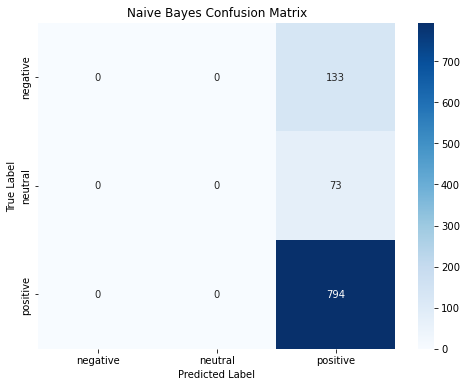

Naive Bayes Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       133
     neutral       0.00      0.00      0.00        73
    positive       0.79      1.00      0.89       794

    accuracy                           0.79      1000
   macro avg       0.26      0.33      0.30      1000
weighted avg       0.63      0.79      0.70      1000

Naive Bayes Error Rate: 0.21



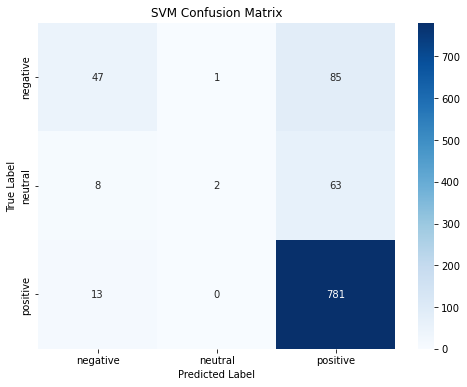

SVM Classification Report:
              precision    recall  f1-score   support

    negative       0.69      0.35      0.47       133
     neutral       0.67      0.03      0.05        73
    positive       0.84      0.98      0.91       794

    accuracy                           0.83      1000
   macro avg       0.73      0.45      0.48      1000
weighted avg       0.81      0.83      0.79      1000

SVM Error Rate: 0.17


In [8]:
# Confusion matrix visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes, title='Confusion Matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

# Plot confusion matrix for Naive Bayes
plot_confusion_matrix(nb_cm, classes=['negative', 'neutral', 'positive'], title='Naive Bayes Confusion Matrix')
print("Naive Bayes Classification Report:")
print(nb_report)
print(f"Naive Bayes Error Rate: {nb_error_rate:.2f}\n")

# Plot confusion matrix for SVM
plot_confusion_matrix(svm_cm, classes=['negative', 'neutral', 'positive'], title='SVM Confusion Matrix')
print("SVM Classification Report:")
print(svm_report)
print(f"SVM Error Rate: {svm_error_rate:.2f}")

In [9]:
# Lexicon-based approach

#TextBlob
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from tabulate import tabulate 

def get_textblob_sentiment(text):
    blob = TextBlob(text)
    tb_polarity = blob.sentiment.polarity

    if tb_polarity > 0:
        return "positive"
    elif tb_polarity < 0:
        return "negative"
    else:
        return "neutral"

df['TextBlob_Prediction'] = df['Cleaned_Text'].apply(get_textblob_sentiment)

# VADER
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']

    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

df['VADER_Prediction'] = df['Cleaned_Text'].apply(get_vader_sentiment)

print("\nSample lexicon-based predictions:")
print(df[['Sentiment', 'TextBlob_Prediction', 'VADER_Prediction']].head())

print("=== Classification Report for TextBlob ===")
print(classification_report(df['Sentiment'], df['TextBlob_Prediction']))
print("Accuracy:", accuracy_score(df['Sentiment'], df['TextBlob_Prediction']))

print("=== Classification Report for VADER ===")
print(classification_report(df['Sentiment'], df['VADER_Prediction']))
print("Accuracy:", accuracy_score(df['Sentiment'], df['VADER_Prediction']))


Sample lexicon-based predictions:
       Sentiment TextBlob_Prediction VADER_Prediction
165256  positive            positive         positive
231465  positive            positive         positive
427827   neutral            negative         positive
433954  negative            positive         positive
70260   positive            positive         positive
=== Classification Report for TextBlob ===
              precision    recall  f1-score   support

    negative       0.51      0.38      0.43       703
     neutral       0.18      0.03      0.06       378
    positive       0.84      0.94      0.88      3919

    accuracy                           0.79      5000
   macro avg       0.51      0.45      0.46      5000
weighted avg       0.74      0.79      0.76      5000

Accuracy: 0.791
=== Classification Report for VADER ===
              precision    recall  f1-score   support

    negative       0.55      0.29      0.38       703
     neutral       0.10      0.03      0.04       37

In [10]:
# Comparing model accuracies

# Add ML predictions to the dataframe
df['NB_Predicted'] = nb_clf.predict(tfidf_vect.transform(df['Cleaned_Text']))
df['SVM_Predicted'] = svm_clf.predict(tfidf_vect.transform(df['Cleaned_Text']))

results = pd.DataFrame({
    'Model': [
        'TextBlob',
        'VADER',
        'Naive Bayes (TF-IDF)',
        'SVM (TF-IDF)'
    ],
    'Accuracy': [
        accuracy_score(df['Sentiment'], df['TextBlob_Prediction']),
        accuracy_score(df['Sentiment'], df['VADER_Prediction']),
        accuracy_score(df['Sentiment'], df['NB_Predicted']),
        accuracy_score(df['Sentiment'], df['SVM_Predicted'])
    ]
})

print("=== Model Comparison ===")
print(results)

# Save processed dataset
df.to_csv("processed_amazon_reviews_final.csv", index=False)
print("\nProcessed CSV file saved successfully.")

=== Model Comparison ===
                  Model  Accuracy
0              TextBlob    0.7910
1                 VADER    0.7922
2  Naive Bayes (TF-IDF)    0.7840
3          SVM (TF-IDF)    0.8968

Processed CSV file saved successfully.


Discussion:

For the lexicon-based approach, TextBlob and VADER were used, whereas Naïve Bayes and SVM were used for the machine learning approach with TF-IDF. The strength of TextBlob and VADER is that they are both simple and fast as they do not require any training data. However, their weakness is that they rely on fixed sentiment words, so the model may not always understand the real context of a review. On the other hand, Naïve Bayes is fast and suitable for text classification but may be less accurate as it treats words independently. In the case of SVM, it is usually more accurate and gives better results, but it takes more time and resources
to run.

Based on the results, SVM had the best performance overall, with the highest accuracy of 0.8968. TextBlob, VADER, and Naïve Bayes had accuracy scores of 0.791, 0.7922, and 0.784 respectively.

One thing that can be seen from the results is that all models performed much better for positive reviews compared to negative and neutral reviews. This is likely due to the fact that the dataset contained far more positive reviews compared to neutral or negative reviews. For example, Naïve Bayes had an accuracy of 0.794, but it did not perform well for negative and neutral reviews as the precision, recall, and F1 scores for those classes were 0.00. This shows that accuracy alone is not enough to judge model performance.

Overall, the machine learning models performed better than the lexicon models, and SVM performed the best, making it the most suitable model for sentiment analysis in this assignment. 